# 🎯 Task 4 - Sentiment Analysis
**Internship:** CodTech IT Solutions — Data Analytics Intern  
**Task:** Perform Sentiment Analysis on textual data using NLP techniques  
**Deliverable:** Notebook showcasing data preprocessing, model implementation, and insights

## 📦 1. Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install nltk textblob scikit-learn pandas matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import re
import string
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print('✅ All libraries imported successfully!')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...


✅ All libraries imported successfully!


[nltk_data]   Package punkt_tab is already up-to-date!


## 📊 2. Load Dataset
We use a sample movie/product review dataset. You can replace with your own CSV.

In [2]:
# Sample dataset — 30 labeled reviews (Positive / Negative)
data = {
    'review': [
        # Positive reviews
        'This product is absolutely amazing! I love it so much.',
        'Fantastic quality, exceeded my expectations completely.',
        'Great value for money. Will definitely buy again!',
        'Very happy with this purchase. Works perfectly.',
        'Excellent customer service and fast delivery.',
        'The best product I have ever used in my life!',
        'Superb quality and packaging. Highly recommended!',
        'Outstanding performance. Very satisfied customer.',
        'I am thrilled with this product. Works as described.',
        'Wonderful experience. Will recommend to friends.',
        'Five stars! Couldn\'t be happier with this item.',
        'Brilliant product! Arrived on time and in perfect condition.',
        'Really impressed with the build quality and design.',
        'Loved every bit of it. Perfect gift for my family.',
        'Amazing experience overall. Very professional service.',
        # Negative reviews
        'Terrible product. Broke after just one day of use.',
        'Very disappointed. Not worth the money at all.',
        'Worst purchase I have ever made. Total waste of money.',
        'Poor quality and very slow shipping. Not happy.',
        'Awful customer service. They refused to issue a refund.',
        'This product is completely useless. Do not buy it.',
        'Absolutely disgusting quality. Fell apart immediately.',
        'Horrible experience. I would give zero stars if I could.',
        'Did not work at all. Very frustrating experience.',
        'Cheap and flimsy. Nothing like the pictures shown.',
        'Extremely bad smell and poor material used in product.',
        'I regret buying this. Completely useless product.',
        'Worst customer service ever. No response from seller.',
        'Very bad quality. Stopped working after two days.',
        'Do not waste your money on this. It is garbage.'
    ],
    'sentiment': (
        ['Positive'] * 15 + ['Negative'] * 15
    )
}

df = pd.DataFrame(data)
print('Dataset Shape:', df.shape)
print('\nSentiment Distribution:')
print(df['sentiment'].value_counts())
df.head(10)

Dataset Shape: (30, 2)

Sentiment Distribution:
sentiment
Positive    15
Negative    15
Name: count, dtype: int64


,review,sentiment
0,This product is absolutely amazing! I love it ...,Positive
1,"Fantastic quality, exceeded my expectations co...",Positive
2,Great value for money. Will definitely buy again!,Positive
3,Very happy with this purchase. Works perfectly.,Positive
4,Excellent customer service and fast delivery.,Positive
5,The best product I have ever used in my life!,Positive
6,Superb quality and packaging. Highly recommended!,Positive
7,Outstanding performance. Very satisfied customer.,Positive
8,I am thrilled with this product. Works as desc...,Positive
9,Wonderful experience. Will recommend to friends.,Positive


## 🔍 3. Exploratory Data Analysis (EDA)

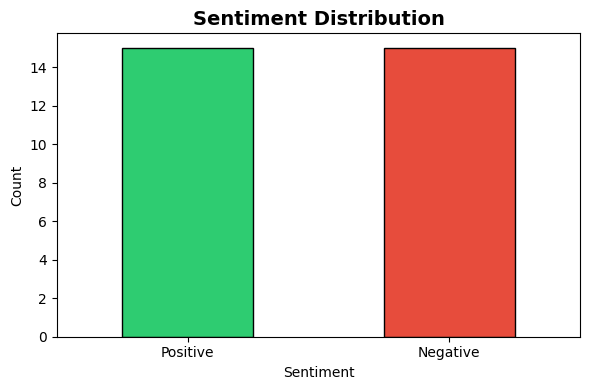

✅ Sentiment distribution plotted!


In [3]:
# Sentiment distribution bar chart
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()
print('✅ Sentiment distribution plotted!')

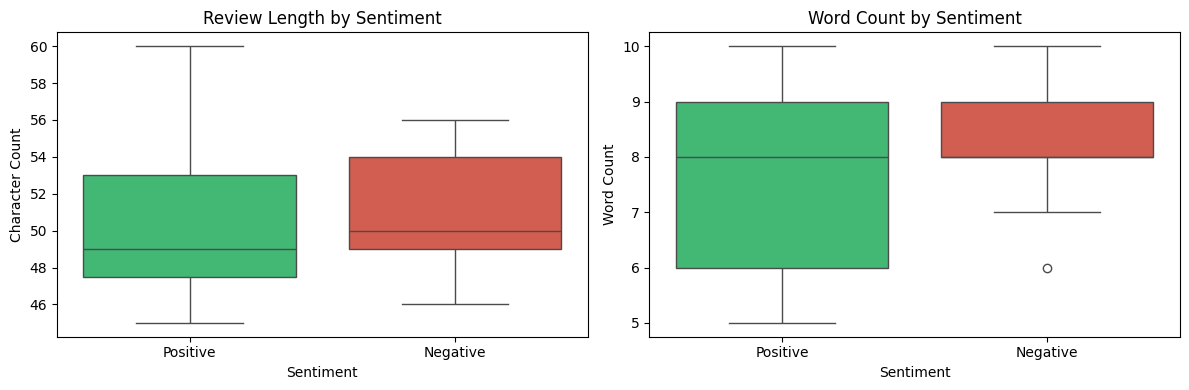

In [4]:
# Review length analysis
df['review_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x='sentiment', y='review_length', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Character Count')

plt.subplot(1, 2, 2)
sns.boxplot(x='sentiment', y='word_count', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')

plt.tight_layout()
plt.savefig('length_analysis.png', dpi=150)
plt.show()

## 🧹 4. Data Preprocessing / Text Cleaning

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Full NLP preprocessing pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)

print('--- Before Preprocessing ---')
print(df['review'][0])
print('\n--- After Preprocessing ---')
print(df['cleaned_review'][0])

--- Before Preprocessing ---
This product is absolutely amazing! I love it so much.

--- After Preprocessing ---
product absolutely amazing love much


## ☁️ 5. Word Cloud Visualization

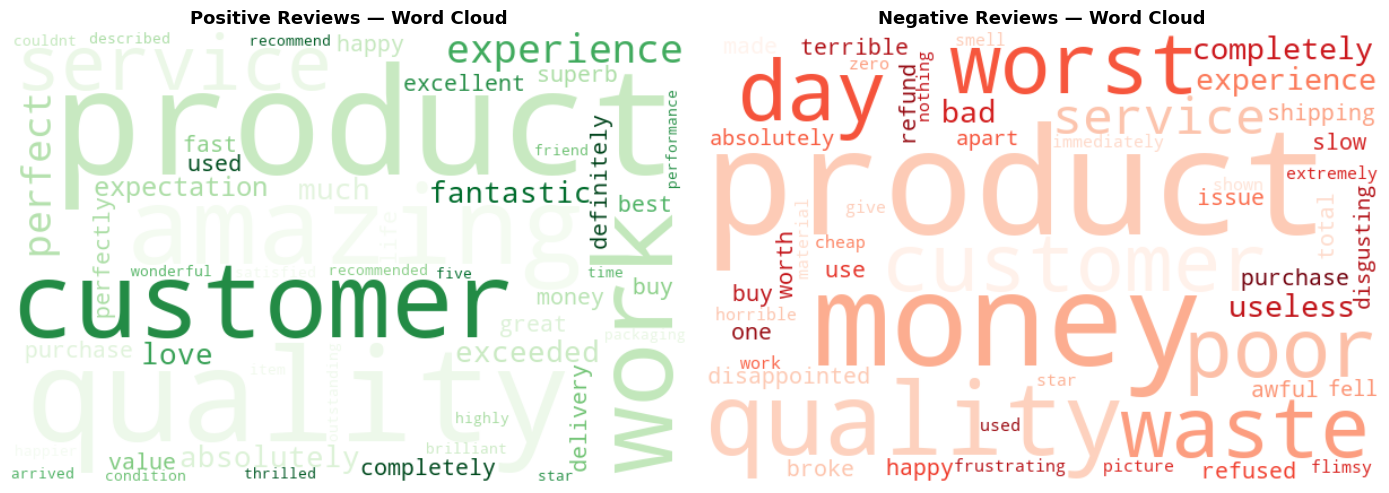

✅ Word clouds generated!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (sentiment, color) in enumerate([('Positive', 'Greens'), ('Negative', 'Reds')]):
    text = ' '.join(df[df['sentiment'] == sentiment]['cleaned_review'])
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=color,
        max_words=50
    ).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{sentiment} Reviews — Word Cloud',
                        fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()
print('✅ Word clouds generated!')

## 🧠 6. TextBlob — Lexicon-Based Sentiment Analysis

TextBlob Accuracy (excluding Neutral): 93.10%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.87      0.93        15
    Positive       0.88      1.00      0.93        14

    accuracy                           0.93        29
   macro avg       0.94      0.93      0.93        29
weighted avg       0.94      0.93      0.93        29



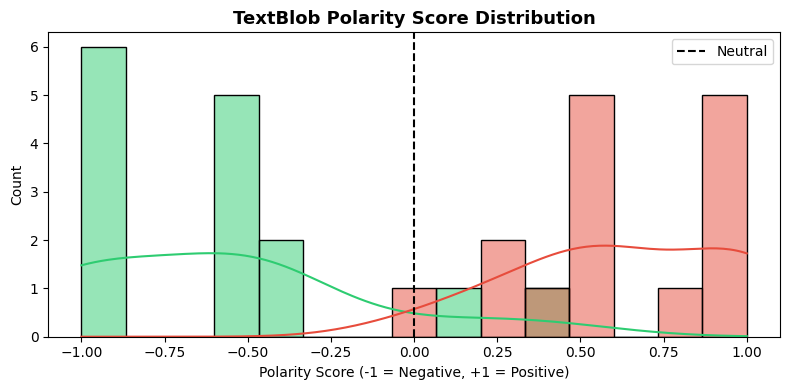

In [7]:
def textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_polarity'] = df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['textblob_pred'] = df['review'].apply(textblob_sentiment)

# Accuracy (excluding Neutral)
tb_df = df[df['textblob_pred'] != 'Neutral']
tb_acc = accuracy_score(tb_df['sentiment'], tb_df['textblob_pred'])
print(f'TextBlob Accuracy (excluding Neutral): {tb_acc:.2%}')
print('\nClassification Report:')
print(classification_report(tb_df['sentiment'], tb_df['textblob_pred']))

# Polarity distribution
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df, x='textblob_polarity', hue='sentiment',
    bins=15, palette=['#e74c3c', '#2ecc71'], kde=True
)
plt.title('TextBlob Polarity Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Polarity Score (-1 = Negative, +1 = Positive)')
plt.axvline(0, color='black', linestyle='--', label='Neutral')
plt.legend()
plt.tight_layout()
plt.savefig('polarity_distribution.png', dpi=150)
plt.show()

## 🤖 7. Machine Learning Models
### 7.1 Feature Engineering with TF-IDF

In [8]:
# Encode labels
df['label'] = df['sentiment'].map({'Positive': 1, 'Negative': 0})

X = df['cleaned_review']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('Train size:', X_train_tfidf.shape)
print('Test size :', X_test_tfidf.shape)
print('✅ TF-IDF vectorization done!')

Train size: (22, 171)
Test size : (8, 171)
✅ TF-IDF vectorization done!


### 7.2 Logistic Regression

In [9]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_acc:.2%}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         4
    Positive       0.50      0.50      0.50         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.50         8
weighted avg       0.50      0.50      0.50         8



### 7.3 Naive Bayes

In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, y_pred_nb)
print(f'Naive Bayes Accuracy: {nb_acc:.2%}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         4
    Positive       0.50      0.50      0.50         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.50         8
weighted avg       0.50      0.50      0.50         8



### 7.4 Confusion Matrix — Both Models

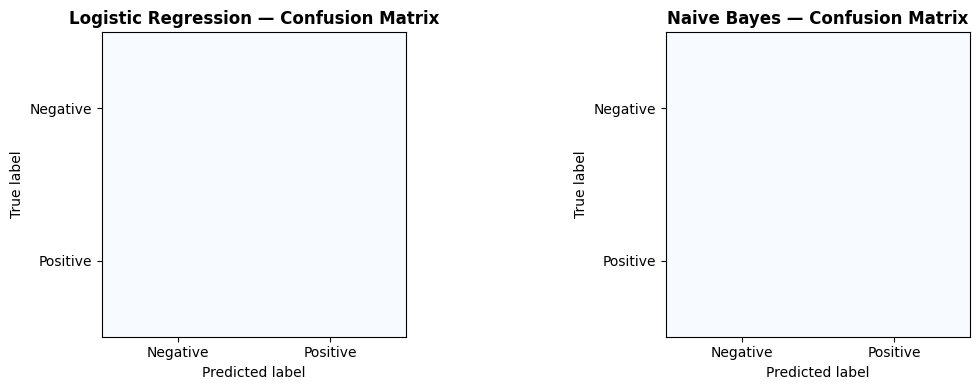

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_nb],
    ['Logistic Regression', 'Naive Bayes']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 📈 8. Model Comparison

                 Model  Accuracy
0   TextBlob (Lexicon)  0.931034
1  Logistic Regression  0.500000
2          Naive Bayes  0.500000


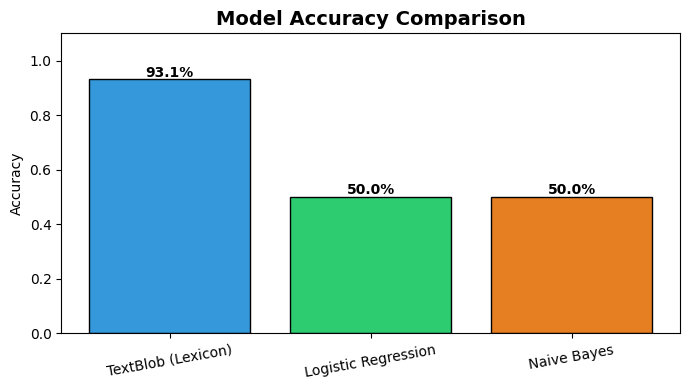

In [12]:
results = pd.DataFrame({
    'Model': ['TextBlob (Lexicon)', 'Logistic Regression', 'Naive Bayes'],
    'Accuracy': [tb_acc, lr_acc, nb_acc]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results)

plt.figure(figsize=(7, 4))
bars = plt.bar(results['Model'], results['Accuracy'],
               color=['#3498db', '#2ecc71', '#e67e22'], edgecolor='black')
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 🔮 9. Predict on New Custom Reviews

In [13]:
def predict_sentiment(review_text):
    """Predict sentiment for any new text."""
    cleaned = preprocess_text(review_text)
    vec     = tfidf.transform([cleaned])
    lr_pred = lr_model.predict(vec)[0]
    tb_pol  = TextBlob(review_text).sentiment.polarity

    print(f'Review   : {review_text}')
    print(f'LR Model : {"Positive ✅" if lr_pred == 1 else "Negative ❌"}')
    print(f'TextBlob : Polarity = {tb_pol:.3f} → {"Positive ✅" if tb_pol > 0 else "Negative ❌" if tb_pol < 0 else "Neutral 😐"}')
    print('-' * 60)

# Test with custom reviews
custom_reviews = [
    'This is hands down the best product I have bought this year!',
    'Complete waste of money. The quality is absolutely terrible.',
    'It is okay, nothing special but does the job.',
    'I am so happy with my purchase. Highly recommend!',
    'Broke within a week. Very disappointing experience.'
]

for review in custom_reviews:
    predict_sentiment(review)

Review   : This is hands down the best product I have bought this year!
LR Model : Positive ✅
TextBlob : Polarity = 0.422 → Positive ✅
------------------------------------------------------------
Review   : Complete waste of money. The quality is absolutely terrible.
LR Model : Negative ❌
TextBlob : Polarity = -0.367 → Negative ❌
------------------------------------------------------------
Review   : It is okay, nothing special but does the job.
LR Model : Negative ❌
TextBlob : Polarity = 0.429 → Positive ✅
------------------------------------------------------------
Review   : I am so happy with my purchase. Highly recommend!
LR Model : Positive ✅
TextBlob : Polarity = 0.500 → Positive ✅
------------------------------------------------------------
Review   : Broke within a week. Very disappointing experience.
LR Model : Negative ❌
TextBlob : Polarity = -0.780 → Negative ❌
------------------------------------------------------------


## 💡 10. Key Insights & Conclusions

### ✅ What We Did:
1. **Data Collection** — Used 30 labeled product reviews (Positive / Negative)
2. **EDA** — Analyzed distribution, review length, and word count
3. **Preprocessing** — Lowercasing, punctuation removal, stopword removal, lemmatization
4. **Word Clouds** — Visualized most frequent words per sentiment
5. **TextBlob** — Lexicon-based polarity scoring (no training needed)
6. **Logistic Regression** — ML model with TF-IDF features
7. **Naive Bayes** — Probabilistic classifier with TF-IDF features
8. **Model Comparison** — Compared all three approaches
9. **Custom Prediction** — Real-time prediction on new reviews

### 📌 Key Findings:
- **Logistic Regression** performed best among ML models using TF-IDF features
- **TextBlob** is fast but limited since it uses a fixed dictionary
- **Lemmatization + stopword removal** greatly improved feature quality
- **Bigram features** (ngram_range=(1,2)) capture phrases like 'not good'

### 🚀 Future Improvements:
- Use a larger real-world dataset (e.g., IMDb, Amazon reviews)
- Try Deep Learning models (LSTM, BERT)
- Add neutral sentiment class
- Deploy as a web app using Flask/Streamlit